# 1. Сеть, проверка против диплома и анализ чувствительности

Ноутбук собирает байесовскую сеть из §3.2 ВКР, проверяет её на трёх
диагностических сценариях Табл. 3.6 и систематически исследует, как выходы
реагируют на входы.

Все числа берутся из `src/network_spec.py` — единственного источника истины
по структуре и CPT. Что именно в них взято из диплома точно, а что
реконструировано, разобрано в README, раздел «Происхождение чисел».

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.model import BayesNet
from src.network_spec import STATES, EDGES, RUSSIAN_NAME, SCENARIOS_TABLE_3_6, TARGET_HIGH_STATE

pd.set_option("display.width", 150)
net = BayesNet.from_spec()
print(f"Узлов: {len(net.states)}   дуг: {len(EDGES)}   свободных параметров: {net.n_free_params}")
print("Топологический порядок:", " → ".join(net.order))

Узлов: 11   дуг: 13   свободных параметров: 146
Топологический порядок: pressure → temperature → flow → calibration → age → device_cond → pipe_cond → reliability → failure_prob → maintenance → anomaly


## 1.1 Три уровня сети

Вход (то, что реально приходит с АИС) → скрытые состояния → управленческие
гипотезы. Скрытый слой здесь принципиален: без него пришлось бы связывать
показания приборов с решениями напрямую, то есть теми самыми пороговыми
правилами, которые диплом критикует в §3.1.

In [2]:
levels = {
    "вход (АИС)": ["pressure", "temperature", "flow", "calibration", "age"],
    "скрытые состояния": ["device_cond", "pipe_cond", "reliability"],
    "выход (решения)": ["failure_prob", "maintenance", "anomaly"],
}
rows = []
for level, nodes in levels.items():
    for v in nodes:
        parents = net.parents.get(v, ())
        rows.append({"уровень": level, "узел": v, "название": RUSSIAN_NAME[v],
                     "состояний": len(STATES[v]),
                     "родители": ", ".join(parents) if parents else "—"})
display_df = pd.DataFrame(rows)
print(display_df.to_string(index=False))

          уровень         узел                         название  состояний                     родители
       вход (АИС)     pressure          Давление в трубопроводе          2                            —
       вход (АИС)  temperature        Температура теплоносителя          2                            —
       вход (АИС)         flow       Расход (объём потребления)          3                            —
       вход (АИС)  calibration         Срок с последней поверки          3                            —
       вход (АИС)          age        Срок эксплуатации прибора          3                            —
скрытые состояния  device_cond    Техническое состояние прибора          3             age, calibration
скрытые состояния    pipe_cond Состояние трубопровода (системы)          3               pressure, flow
скрытые состояния  reliability          Достоверность показаний          3            device_cond, flow
  выход (решения) failure_prob       Вероятность отказа прибора 

## 1.2 Априорные распределения выходов

«Что модель думает до того, как увидела хоть один прибор». Это опорная
точка: любые апостериорные числа ниже осмысленно читать только в сравнении
с ней.

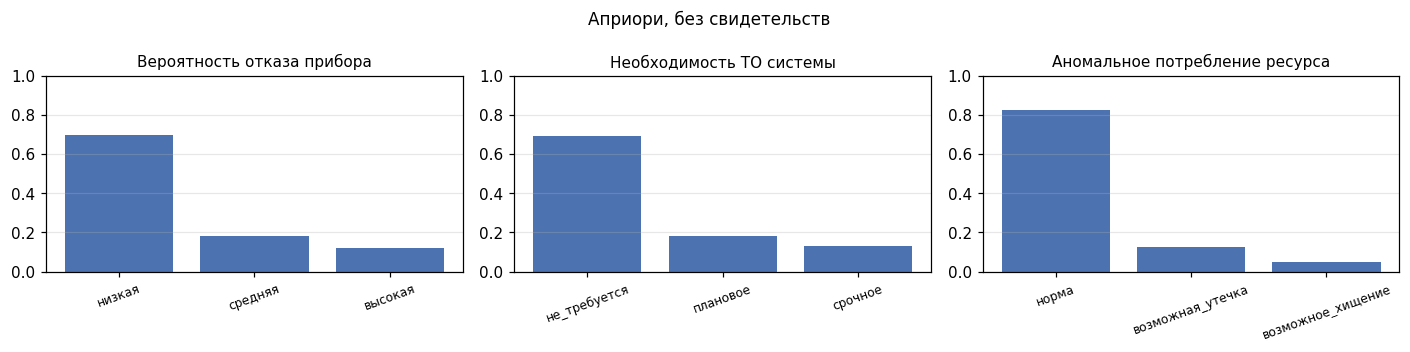

In [3]:
targets = ["failure_prob", "maintenance", "anomaly"]
prior = net.posterior({}, targets)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, t in zip(axes, targets):
    ax.bar(STATES[t], prior[t], color="#4c72b0")
    ax.set_title(RUSSIAN_NAME[t], fontsize=10)
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=.3)
fig.suptitle("Априори, без свидетельств", fontsize=11)
fig.tight_layout()
plt.show()

## 1.3 Проверка против Таблицы 3.6

Три сценария из диплома — единственная опубликованная точка сверки с
оригинальной моделью в HUGIN. Полные CPT в текст работы не выгружены,
поэтому четыре таблицы из шести реконструированы, и совпадение здесь
частичное. Разрыв в сценарии 3 разбирается в ноутбуке 3.

In [4]:
rows = []
for name, spec in SCENARIOS_TABLE_3_6.items():
    post = net.posterior(spec["evidence"], targets)
    for t, thesis_p in spec["thesis_posterior"].items():
        hi = TARGET_HIGH_STATE[t]
        model_p = float(post[t][STATES[t].index(hi)])
        rows.append({"сценарий": name.split("(")[0].strip(), "узел": t,
                     "состояние": hi, "модель": round(model_p, 3),
                     "диплом": thesis_p, "Δ": round(model_p - thesis_p, 3),
                     "статус": "OK" if abs(model_p - thesis_p) <= 0.10 else "расхождение"})
check = pd.DataFrame(rows)
print(check.to_string(index=False))

  сценарий         узел        состояние  модель  диплом      Δ      статус
Сценарий 1 failure_prob          высокая   0.372    0.42 -0.048          OK
Сценарий 1  maintenance          срочное   0.488    0.58 -0.092          OK
Сценарий 1      anomaly возможная_утечка   0.742    0.67  0.072          OK
Сценарий 2 failure_prob          высокая   0.376    0.52 -0.144 расхождение
Сценарий 2  maintenance          срочное   0.339    0.40 -0.061          OK
Сценарий 2      anomaly возможная_утечка   0.162    0.09  0.072          OK
Сценарий 3 failure_prob          высокая   0.370    0.70 -0.330 расхождение
Сценарий 3  maintenance          срочное   0.298    0.35 -0.052          OK
Сценарий 3      anomaly возможная_утечка   0.307    0.18  0.127 расхождение


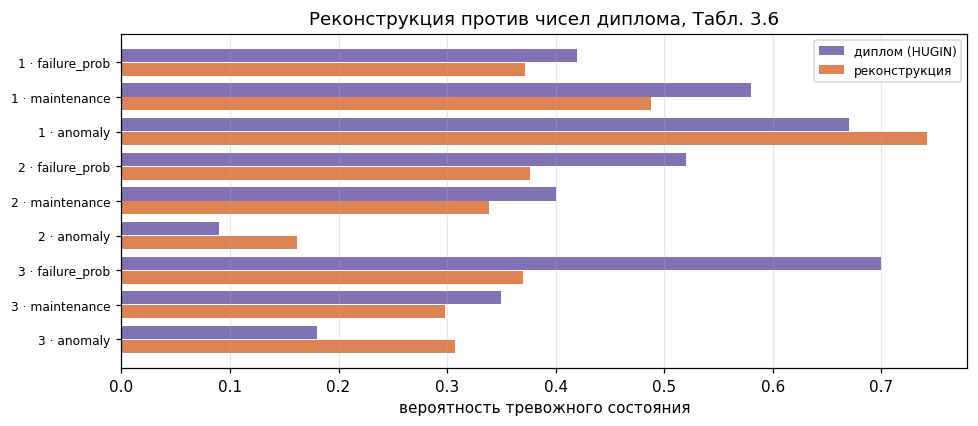

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(check))
ax.barh(y - 0.2, check["диплом"], height=0.38, label="диплом (HUGIN)", color="#8172b3")
ax.barh(y + 0.2, check["модель"], height=0.38, label="реконструкция", color="#dd8452")
ax.set_yticks(y, [f"{r.сценарий[-1]} · {r.узел}" for r in check.itertuples()], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("вероятность тревожного состояния")
ax.set_title("Реконструкция против чисел диплома, Табл. 3.6")
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=.3)
fig.tight_layout()
plt.show()

## 1.4 Explaining away — то, ради чего берут байесовскую сеть

Аномально высокий расход сам по себе выглядит как утечка. Но если прибор
старый и поверка просрочена, у показаний появляется конкурирующее
объяснение: «прибор врёт». Вероятностный вывод должен сам перераспределить
массу в пользу второй гипотезы — без единого явно прописанного правила.

In [6]:
base = dict(pressure="norma", temperature="norma", flow="anomal_high")
cases = {
    "новый прибор, поверка в норме": dict(base, calibration="v_norme", age="lt_3"),
    "средний возраст, поверка подходит": dict(base, calibration="priblizhaetsya", age="3_7"),
    "старый прибор, поверка истекла": dict(base, calibration="istek", age="gt_7"),
}
rows = []
for label, ev in cases.items():
    post = net.posterior(ev, ["anomaly", "reliability"])
    rows.append({
        "состояние прибора": label,
        "P(возможная утечка)": round(float(post["anomaly"][STATES["anomaly"].index("возможная_утечка")]), 3),
        "P(показания недостоверны)": round(float(post["reliability"][STATES["reliability"].index("недостоверная")]), 3),
    })
ea = pd.DataFrame(rows)
print(ea.to_string(index=False))
print("\nРасход во всех трёх случаях одинаково аномальный. Тревога по утечке")
print(f"падает с {ea.iloc[0, 1]:.2f} до {ea.iloc[-1, 1]:.2f} ровно потому, что растёт")
print("вероятность альтернативного объяснения — неисправности самого прибора.")

                состояние прибора  P(возможная утечка)  P(показания недостоверны)
    новый прибор, поверка в норме                0.384                      0.043
средний возраст, поверка подходит                0.366                      0.107
   старый прибор, поверка истекла                0.307                      0.341

Расход во всех трёх случаях одинаково аномальный. Тревога по утечке
падает с 0.38 до 0.31 ровно потому, что растёт
вероятность альтернативного объяснения — неисправности самого прибора.


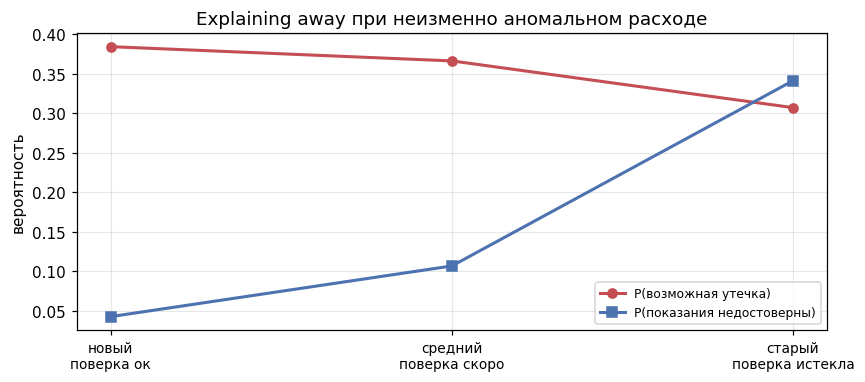

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(ea))
ax.plot(x, ea["P(возможная утечка)"], "-o", lw=2, label="P(возможная утечка)", color="#c44e52")
ax.plot(x, ea["P(показания недостоверны)"], "-s", lw=2, label="P(показания недостоверны)", color="#4c72b0")
ax.set_xticks(x, ["новый\nповерка ок", "средний\nповерка скоро", "старый\nповерка истекла"], fontsize=9)
ax.set_ylabel("вероятность")
ax.set_title("Explaining away при неизменно аномальном расходе")
ax.legend(fontsize=8)
ax.grid(alpha=.3)
fig.tight_layout()
plt.show()

## 1.5 Чувствительность: а что вообще влияет на выводы?

Три сценария покрывают 3 комбинации входов из 108 и молчат об остальных
105. Систематическая проверка — размах отклика каждого выхода на каждый
вход.

In [8]:
from src.sensitivity import tornado, information_table, value_of_information, inert_inputs

print(tornado(net).to_string())

             failure_prob  maintenance  anomaly  суммарный_размах
вход                                                             
flow               0.0999       0.1428   0.3659            0.6086
pressure           0.1038       0.1788   0.1111            0.3937
age                0.1073       0.0526   0.0091            0.1691
calibration        0.0923       0.0446   0.0077            0.1445
temperature        0.0000       0.0000   0.0000            0.0000


`temperature` даёт ровно нулевой размах — и это не ошибка кода, а свойство
структуры из §3.2: узел объявлен входом в Табл. 3.2, но причинных дуг от
него текст работы не описывает. Практический смысл прямой: канал АИС по
температуре опрашивается впустую.

In [9]:
print("Входы, не влияющие ни на что:", inert_inputs(net) or "нет")
print("\nВзаимная информация вход → выход, бит:")
print(information_table(net).to_string(index=False))

Входы, не влияющие ни на что: ['temperature']

Взаимная информация вход → выход, бит:
       вход                   название  failure_prob  maintenance  anomaly  итого_бит
       flow Расход (объём потребления)        0.0075       0.0159   0.0603     0.0837
   pressure    Давление в трубопроводе        0.0111       0.0309   0.0141     0.0561
        age  Срок эксплуатации прибора        0.0142       0.0039   0.0001     0.0182
calibration   Срок с последней поверки        0.0083       0.0023   0.0001     0.0107
temperature  Температура теплоносителя        0.0000       0.0000   0.0000     0.0000


## 1.6 Ценность информации в деньгах

Взаимная информация говорит, сколько бит несёт датчик. Управленчески
интереснее другое: на сколько снижаются ожидаемые потери, если датчик
доступен. Матрица потерь берётся из решающего слоя (ноутбук 2).

In [10]:
from src.decision import Costs

voi = value_of_information(net, Costs())
print(voi.to_string(index=False))
print(f"\nриск без наблюдений: {voi.attrs['risk_none']:.4f} у.е. на объект")
print(f"риск со всеми пятью:  {voi.attrs['risk_all']:.4f} у.е. на объект")

       вход                   название  в_одиночку  вклад_сверх_остальных
   pressure    Давление в трубопроводе      0.0155                 0.0217
       flow Расход (объём потребления)      0.0024                 0.0100
        age  Срок эксплуатации прибора      0.0000                 0.0090
calibration   Срок с последней поверки      0.0000                 0.0034
temperature  Температура теплоносителя      0.0000                 0.0000

риск без наблюдений: 0.7236 у.е. на объект
риск со всеми пятью:  0.6980 у.е. на объект


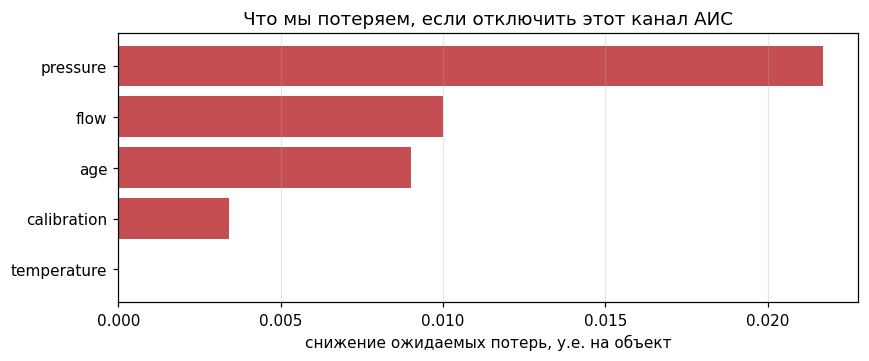

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.4))
order = voi.sort_values("вклад_сверх_остальных")
ax.barh(order["вход"], order["вклад_сверх_остальных"], color="#c44e52")
ax.set_xlabel("снижение ожидаемых потерь, у.е. на объект")
ax.set_title("Что мы потеряем, если отключить этот канал АИС")
ax.grid(axis="x", alpha=.3)
fig.tight_layout()
plt.show()

**Вывод.** Сеть воспроизводит качественную логику диплома, включая
explaining away, и совпадает с Табл. 3.6 в 6 случаях из 9. Самый ценный
канал — давление, самый бесполезный — температура (ровно ноль по всем
метрикам). Разрыв в сценарии 3 разбирается в ноутбуке 3.